# W1-D1 — Phát hiện Anomaly trên Metric

**Dataset:** NAB `realKnownCause/nyc_taxi.csv` (nhu cầu taxi NYC, lấy mẫu mỗi 30 phút,
2014-07-01 → 2015-01-31, 10,320 điểm). Chọn dataset này vì nó có **cửa sổ anomaly
đã gán nhãn ground-truth** (NYC Marathon, Lễ Tạ ơn, Giáng sinh, Năm mới, bão tuyết
cuối tháng 1) và có seasonality ngày + tuần rõ rệt — lý tưởng để cho thấy vì sao cần
một detector statistical hiểu seasonal (STL) và so sánh nó với một detector ML dựa
trên feature (Isolation Forest).

**Pipeline:** Phase 1 EDA → Phase 2 hai detector (STL+3σ, Isolation Forest) →
Phase 3 so sánh/tuning/reflection → Bonus (EWMA, log-transform, multivariate).

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import IsolationForest
import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 110

DATA = "data/nyc_taxi.csv"
WINDOWS_JSON = "data/combined_windows.json"
LABEL_KEY = "realKnownCause/nyc_taxi.csv"

STEP_MIN = 30                 # bước thời gian của data (phút)
PERIOD_DAY = 24 * 60 // STEP_MIN     # 48 điểm  = 1 ngày
PERIOD_WEEK = PERIOD_DAY * 7         # 336 điểm = 1 tuần
print(f"chu kỳ ngày = {PERIOD_DAY} điểm | chu kỳ tuần = {PERIOD_WEEK} điểm")

chu kỳ ngày = 48 điểm | chu kỳ tuần = 336 điểm


## Phase 1 — EDA & Hiểu Data

In [2]:
# Load chuỗi dữ liệu
df = pd.read_csv(DATA, parse_dates=["timestamp"]).set_index("timestamp")
s = df["value"].astype(float)

# Dựng ground-truth theo từng điểm từ các cửa sổ anomaly của NAB
windows = json.load(open(WINDOWS_JSON))[LABEL_KEY]
windows = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in windows]
gt = pd.Series(False, index=s.index)
for a, b in windows:
    gt[(s.index >= a) & (s.index <= b)] = True

print(f"số dòng={len(s)}  khoảng thời gian={s.index.min()} -> {s.index.max()}")
print(f"số điểm anomaly đã gán nhãn = {int(gt.sum())} ({100*gt.mean():.2f}% của data)")
print(f"số cửa sổ anomaly = {len(windows)}")
for i, (a, b) in enumerate(windows, 1):
    print(f"  sự kiện {i}: {a}  ->  {b}  ({(b-a)})")

số dòng=10320  khoảng thời gian=2014-07-01 00:00:00 -> 2015-01-31 23:30:00
số điểm anomaly đã gán nhãn = 1035 (10.03% của data)
số cửa sổ anomaly = 5
  sự kiện 1: 2014-10-30 15:30:00  ->  2014-11-03 22:30:00  (4 days 07:00:00)
  sự kiện 2: 2014-11-25 12:00:00  ->  2014-11-29 19:00:00  (4 days 07:00:00)
  sự kiện 3: 2014-12-23 11:30:00  ->  2014-12-27 18:30:00  (4 days 07:00:00)
  sự kiện 4: 2014-12-29 21:30:00  ->  2015-01-03 04:30:00  (4 days 07:00:00)
  sự kiện 5: 2015-01-24 20:30:00  ->  2015-01-29 03:30:00  (4 days 07:00:00)


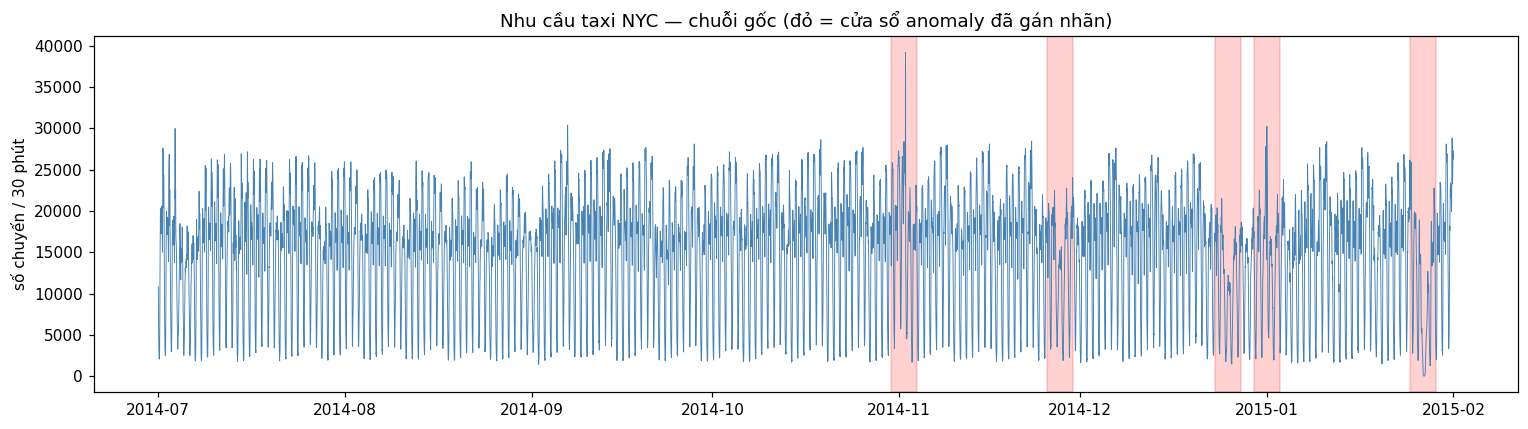

In [3]:
# Chuỗi thời gian gốc, tô màu các cửa sổ anomaly
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s.index, s.values, lw=0.6, color="steelblue")
for a, b in windows:
    ax.axvspan(a, b, color="red", alpha=0.18)
ax.set_title("Nhu cầu taxi NYC — chuỗi gốc (đỏ = cửa sổ anomaly đã gán nhãn)")
ax.set_ylabel("số chuyến / 30 phút")
plt.tight_layout()
plt.savefig("figures/01_raw_series.png", bbox_inches="tight")
plt.show()

In [4]:
# Thống kê cơ bản
desc = {
    "mean": s.mean(), "std": s.std(), "min": s.min(), "median": s.median(),
    "max": s.max(), "skewness": stats.skew(s), "kurtosis": stats.kurtosis(s),
}
stats_tbl = pd.DataFrame.from_dict(desc, orient="index", columns=["value"]).round(3)
print(stats_tbl.to_string())
sk = stats.skew(s)
print(f"\n|skewness| = {abs(sk):.3f} -> " +
      ("gần Gaussian (<0.5), dùng 3σ trên phân phối gốc chấp nhận được" if abs(sk) < 0.5
       else "bị skew, cẩn thận khi dùng 3σ"))

              value
mean      15137.569
std        6939.496
min           8.000
median    16778.000
max       39197.000
skewness     -0.452
kurtosis     -0.780

|skewness| = 0.452 -> gần Gaussian (<0.5), dùng 3σ trên phân phối gốc chấp nhận được


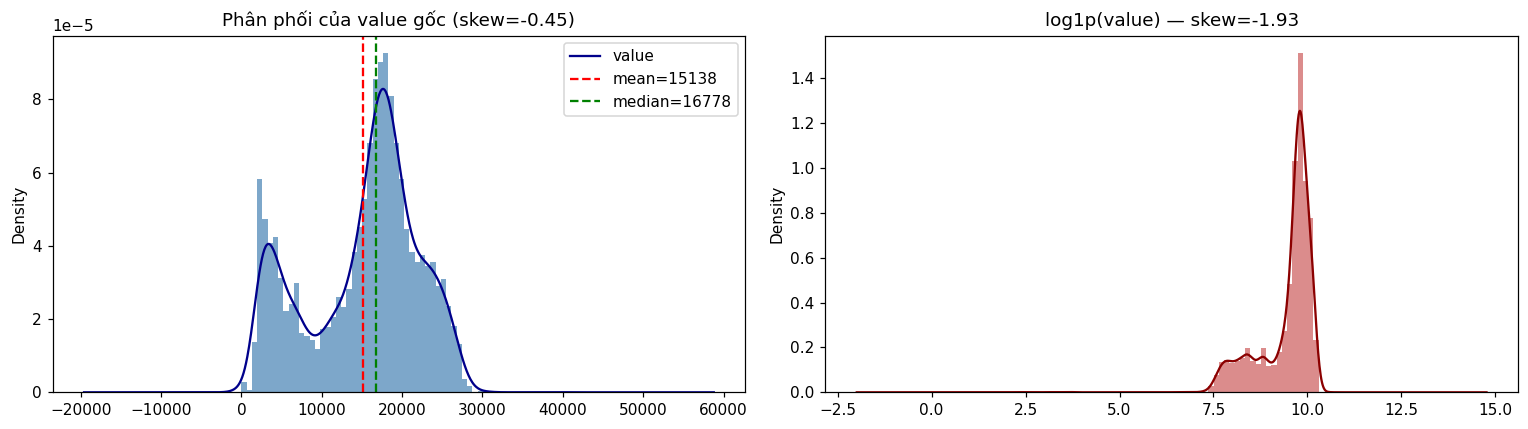

skew gốc   = -0.452
skew log1p = -1.927  -> log làm |skew| LỚN HƠN, nên log-transform KHÔNG phù hợp ở đây
Diễn giải: value bị LỆCH TRÁI nhẹ; log chỉ giúp data LỆCH PHẢI.


In [5]:
# Phân phối: histogram + KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(s, bins=60, density=True, color="steelblue", alpha=0.7)
s.plot.kde(ax=axes[0], color="darkblue")
axes[0].axvline(s.mean(), color="red", ls="--", label=f"mean={s.mean():.0f}")
axes[0].axvline(s.median(), color="green", ls="--", label=f"median={s.median():.0f}")
axes[0].set_title(f"Phân phối của value gốc (skew={sk:.2f})")
axes[0].legend()

# So sánh với biến đổi log1p (có giúp ích không?)
log_s = np.log1p(s)
axes[1].hist(log_s, bins=60, density=True, color="indianred", alpha=0.7)
log_s.plot.kde(ax=axes[1], color="darkred")
axes[1].set_title(f"log1p(value) — skew={stats.skew(log_s):.2f}")
plt.tight_layout()
plt.savefig("figures/02_distribution.png", bbox_inches="tight")
plt.show()
print(f"skew gốc   = {sk:.3f}")
print(f"skew log1p = {stats.skew(log_s):.3f}  -> log làm |skew| LỚN HƠN, nên log-transform KHÔNG phù hợp ở đây")
print("Diễn giải: value bị LỆCH TRÁI nhẹ; log chỉ giúp data LỆCH PHẢI.")

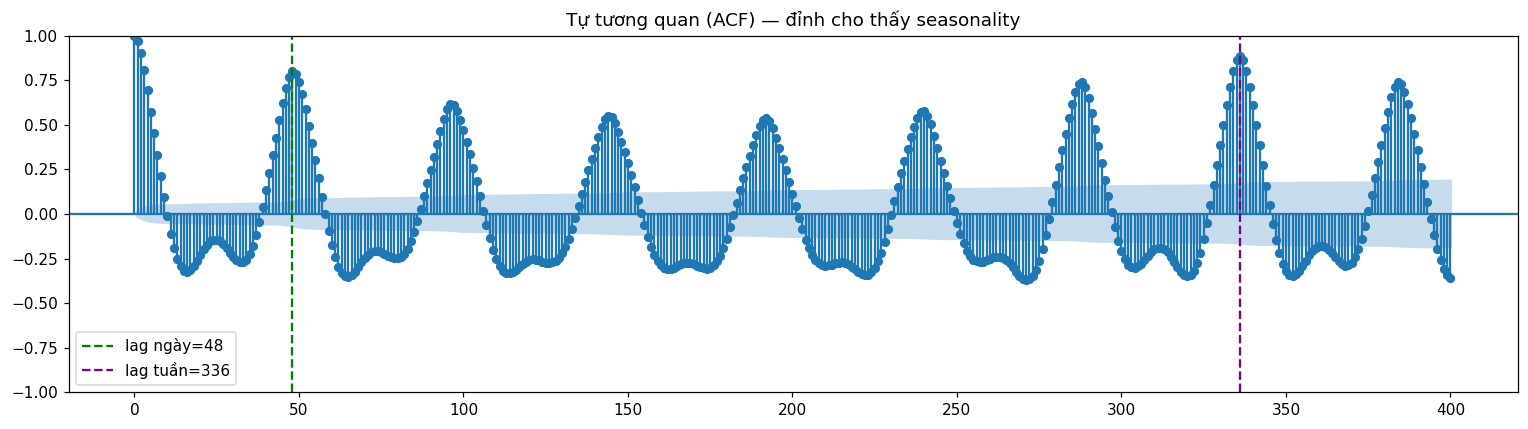

ACF tại lag ngày  48  = 0.799
ACF tại lag tuần 336 = 0.887
-> tự tương quan mạnh ở cả chu kỳ NGÀY và TUẦN => data seasonal. Chu kỳ tuần (336) là chu kỳ đơn rộng nhất và đã bao trùm chu kỳ ngày.


In [6]:
# ACF — phát hiện seasonality / chu kỳ
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(s, lags=400, ax=ax)
ax.axvline(PERIOD_DAY, color="green", ls="--", label=f"lag ngày={PERIOD_DAY}")
ax.axvline(PERIOD_WEEK, color="purple", ls="--", label=f"lag tuần={PERIOD_WEEK}")
ax.set_title("Tự tương quan (ACF) — đỉnh cho thấy seasonality")
ax.legend()
plt.tight_layout()
plt.savefig("figures/03_acf.png", bbox_inches="tight")
plt.show()

# Định lượng các đỉnh ACF tại những chu kỳ ứng viên
from statsmodels.tsa.stattools import acf as _acf
a = _acf(s, nlags=PERIOD_WEEK + 5)
print(f"ACF tại lag ngày  {PERIOD_DAY}  = {a[PERIOD_DAY]:.3f}")
print(f"ACF tại lag tuần {PERIOD_WEEK} = {a[PERIOD_WEEK]:.3f}")
print("-> tự tương quan mạnh ở cả chu kỳ NGÀY và TUẦN => data seasonal. "
      "Chu kỳ tuần (336) là chu kỳ đơn rộng nhất và đã bao trùm chu kỳ ngày.")

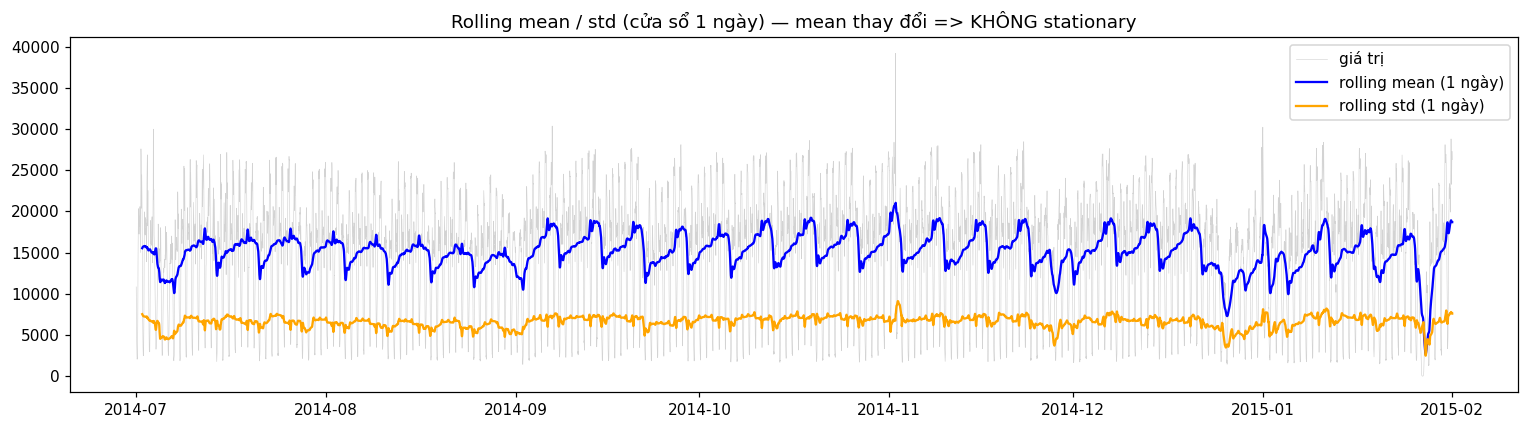

In [7]:
# Kiểm tra stationarity — rolling mean/std trên cửa sổ 1 ngày
roll = s.rolling(PERIOD_DAY)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s.index, s, lw=0.4, color="lightgray", label="giá trị")
ax.plot(s.index, roll.mean(), color="blue", label="rolling mean (1 ngày)")
ax.plot(s.index, roll.std(), color="orange", label="rolling std (1 ngày)")
ax.set_title("Rolling mean / std (cửa sổ 1 ngày) — mean thay đổi => KHÔNG stationary")
ax.legend()
plt.tight_layout()
plt.savefig("figures/04_stationarity.png", bbox_inches="tight")
plt.show()

### Phase 1 — Kết luận

| Tính chất | Phát hiện | Bằng chứng |
|---|---|---|
| Phân phối | lệch **trái** nhẹ, gần Gaussian (skew ≈ −0.45) | histogram + chỉ số skew |
| Log-transform | **không phù hợp** — làm skew xấu hơn (−0.45 → −1.9) | panel 2 |
| Seasonality | chu kỳ **ngày (48)** + **tuần (336)** mạnh | đỉnh ACF |
| Stationarity | **không stationary** (mean seasonal thay đổi theo giờ/ngày) | đồ thị rolling-mean |

**Chọn phương pháp:** data *seasonal và non-stationary*, nên một ngưỡng global 3σ
duy nhất sẽ thất bại — dao động seasonal làm phồng std tới mức band rộng hơn cả data
(cận dưới âm), và mất ngữ cảnh thời gian trong ngày (một giá trị bình thường lúc trưa
có thể là anomaly lúc 3h sáng). Detector statistical đúng là **STL decomposition +
3σ trên residual**, bỏ cấu trúc ngày+tuần đi trước. Với detector ML, **Isolation
Forest trên các feature thời gian** có thể dùng trực tiếp ngữ cảnh seasonal (giờ,
thứ trong tuần, độ lệch so với rolling-mean).

## Phase 2 — Hai Detector

Cách đánh giá chung: nhãn NAB là các **cửa sổ** 4 ngày (≈10% số điểm), trong khi
detector chỉ flag những điểm lệch sắc nhọn — nên recall theo điểm tự nhiên sẽ thấp.
Vì vậy ta báo cáo **cả** P/R/F1 theo điểm **và** mức phát hiện theo sự kiện
(bao nhiêu trong 5 sự kiện đã biết có ≥1 flag).

In [8]:
def evaluate(pred, truth):
    """Các chỉ số confusion theo điểm. pred/truth: mảng boolean cùng độ dài."""
    pred = np.asarray(pred, dtype=bool)
    truth = np.asarray(truth, dtype=bool)
    tp = int((pred & truth).sum())
    fp = int((pred & ~truth).sum())
    fn = int((~pred & truth).sum())
    tn = int((~pred & ~truth).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0
    return dict(TP=tp, FP=fp, FN=fn, precision=round(prec, 3),
                recall=round(rec, 3), f1=round(f1, 3),
                false_alarm_rate=round(far, 4))


def events_caught(pred_series):
    """Bao nhiêu cửa sổ đã gán nhãn chứa >=1 điểm dự đoán là anomaly. pred_series: bool, index theo timestamp."""
    caught = 0
    for a, b in windows:
        m = (pred_series.index >= a) & (pred_series.index <= b)
        if pred_series[m].any():
            caught += 1
    return caught, len(windows)


def plot_detector(pred_series, title, path):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(s.index, s.values, lw=0.5, color="steelblue", label="giá trị")
    for a, b in windows:
        ax.axvspan(a, b, color="red", alpha=0.12)
    flagged = pred_series[pred_series]
    ax.scatter(flagged.index, s.loc[flagged.index], color="red", s=14,
               zorder=5, label="anomaly phát hiện được")
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()

### Detector 1 — STL + 3σ (statistical, chọn từ EDA)

Trước tiên là một baseline nhanh cho thấy **vì sao global 3σ đơn lẻ sai ở đây**, rồi tới STL.

In [9]:
# Baseline: GLOBAL 3σ ngây thơ trên chuỗi gốc (một ngưỡng tĩnh duy nhất, không xét seasonality)
g_mean, g_std = s.mean(), s.std()
upper, lower = g_mean + 3 * g_std, g_mean - 3 * g_std
pred_global = (s > upper) | (s < lower)
m_global = evaluate(pred_global.values, gt.values)
ecg = events_caught(pred_global)
print(f"Band global 3σ = [{lower:.0f}, {upper:.0f}]  (data min={s.min():.0f}, max={s.max():.0f})")
print("Baseline global 3σ:", m_global, f"sự kiện={ecg[0]}/5")
print("-> dao động seasonal làm phồng std global, nên band RỘNG hơn cả data và cận dưới "
      "âm (vô nghĩa). Nó bỏ sót hết các đợt tụt ngày lễ và mất ngữ cảnh thời gian trong "
      "ngày. Một ngưỡng tĩnh duy nhất không thể mô hình hóa seasonality ngày/đêm -> "
      "cần STL.")

Band global 3σ = [-5681, 35956]  (data min=8, max=39197)
Baseline global 3σ: {'TP': 1, 'FP': 0, 'FN': 1034, 'precision': 1.0, 'recall': 0.001, 'f1': 0.002, 'false_alarm_rate': 0.0} sự kiện=1/5
-> dao động seasonal làm phồng std global, nên band RỘNG hơn cả data và cận dưới âm (vô nghĩa). Nó bỏ sót hết các đợt tụt ngày lễ và mất ngữ cảnh thời gian trong ngày. Một ngưỡng tĩnh duy nhất không thể mô hình hóa seasonality ngày/đêm -> cần STL.


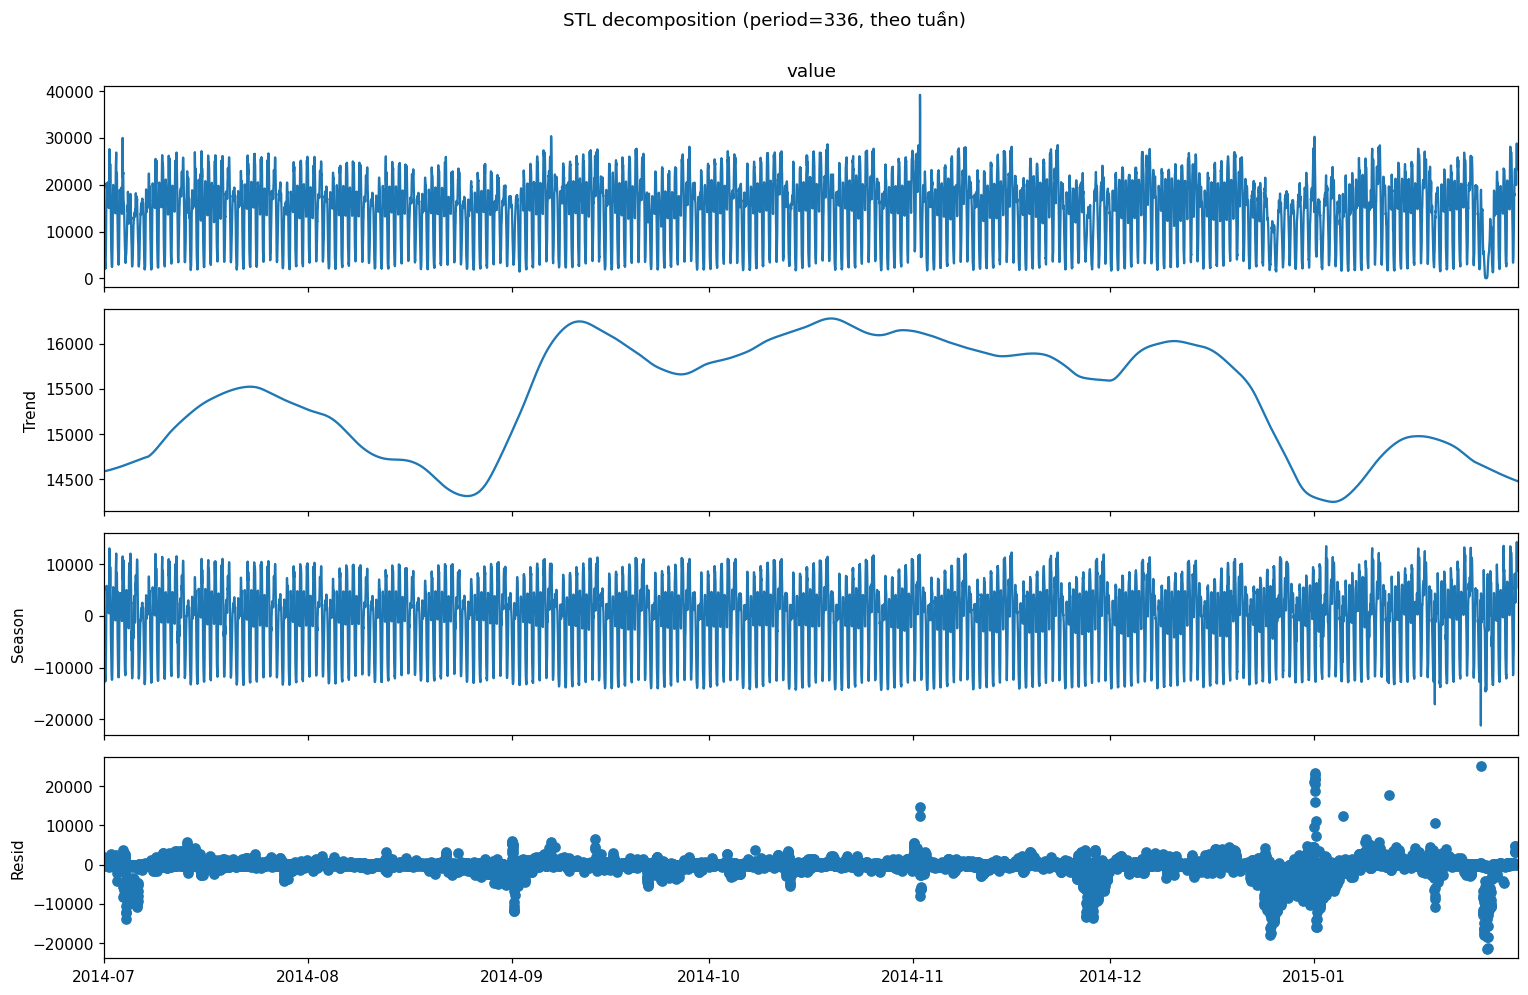

In [10]:
# STL decomposition (chu kỳ tuần, robust=True để anomaly không làm méo phần fit)
stl = STL(s, period=PERIOD_WEEK, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(14, 9)
fig.suptitle("STL decomposition (period=336, theo tuần)", y=1.0)
plt.tight_layout()
plt.savefig("figures/05_stl_decomposition.png", bbox_inches="tight")
plt.show()

STL + 3.0σ: {'TP': 194, 'FP': 61, 'FN': 841, 'precision': 0.761, 'recall': 0.187, 'f1': 0.301, 'false_alarm_rate': 0.0066} sự kiện=5/5


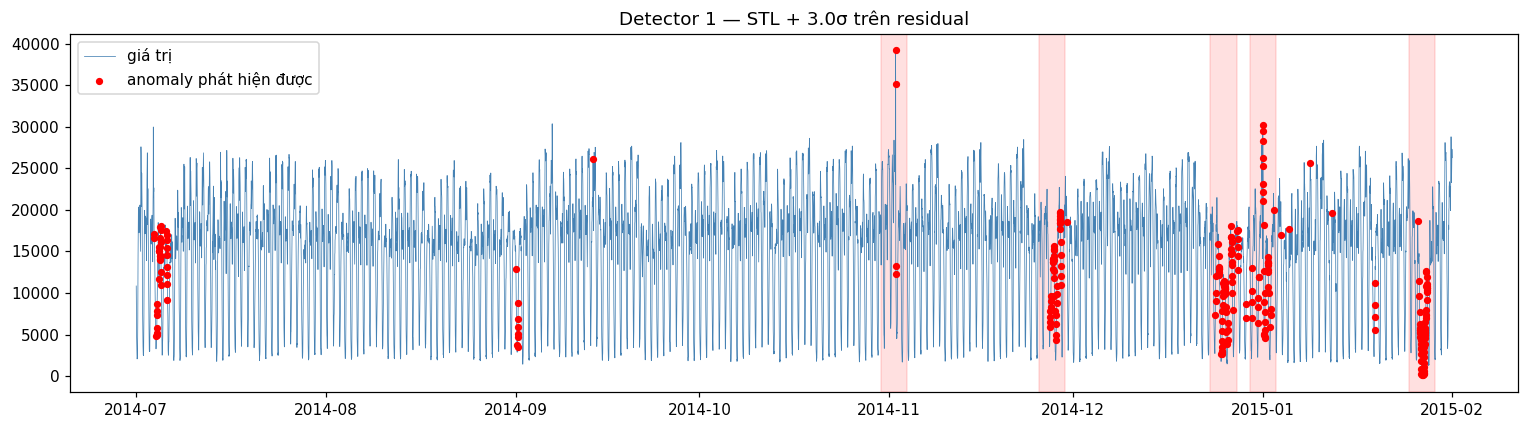

In [11]:
# 3σ trên residual của STL
resid = stl.resid
r_mean, r_std = resid.mean(), resid.std()
STL_THRESHOLD = 3.0
z_resid = (resid - r_mean) / r_std
pred_stl = (z_resid.abs() > STL_THRESHOLD)
m_stl = evaluate(pred_stl.values, gt.values)
ec_stl = events_caught(pred_stl)
print(f"STL + {STL_THRESHOLD}σ:", m_stl, f"sự kiện={ec_stl[0]}/{ec_stl[1]}")
plot_detector(pred_stl, f"Detector 1 — STL + {STL_THRESHOLD}σ trên residual",
              "figures/06_detector1_stl.png")

### Detector 2 — Isolation Forest (ML, có feature engineering)

In [12]:
def build_features(series, window=PERIOD_DAY):
    """Biến một chuỗi metric 1 chiều thành bảng feature giàu ngữ cảnh cho IF."""
    x = pd.Series(series)
    feats = pd.DataFrame({
        "value": x,
        "rolling_mean_1d": x.rolling(window).mean(),
        "rolling_std_1d": x.rolling(window).std(),
        "rate_of_change": x.diff(),
        "rate_of_change_1d": x.diff(window),
        "lag_1": x.shift(1),
        "lag_1d": x.shift(window),
        "hour": x.index.hour,
        "dayofweek": x.index.dayofweek,
        "is_weekend": (x.index.dayofweek >= 5).astype(int),
        "z_score": (x - x.rolling(window).mean()) /
                   x.rolling(window).std().replace(0, 1e-10),
    }, index=x.index)
    return feats.dropna()


X = build_features(s)
gt_X = gt.loc[X.index]
print(f"bảng feature: {X.shape[0]} dòng x {X.shape[1]} feature")
print("các feature:", list(X.columns))

bảng feature: 10272 dòng x 11 feature
các feature: ['value', 'rolling_mean_1d', 'rolling_std_1d', 'rate_of_change', 'rate_of_change_1d', 'lag_1', 'lag_1d', 'hour', 'dayofweek', 'is_weekend', 'z_score']


In [13]:
# Tune contamination — ghi log precision/recall/F1 cho từng giá trị
print("=== Quét contamination cho Isolation Forest ===")
if_sweep = []
if_models = {}
for c in (0.01, 0.02, 0.05):
    clf = IsolationForest(n_estimators=200, contamination=c,
                          max_features=1.0, random_state=42)
    clf.fit(X)
    pred = pd.Series(clf.predict(X) == -1, index=X.index)
    m = evaluate(pred.values, gt_X.values)
    ec = events_caught(pred)
    if_models[c] = (clf, pred)
    row = dict(contamination=c, **m, events=f"{ec[0]}/{ec[1]}")
    if_sweep.append(row)
    print(f"contamination={c}: P={m['precision']} R={m['recall']} "
          f"F1={m['f1']} FP={m['FP']} sự kiện={ec[0]}/{ec[1]}")

if_sweep_df = pd.DataFrame(if_sweep).set_index("contamination")
print()
print(if_sweep_df.to_string())

=== Quét contamination cho Isolation Forest ===


contamination=0.01: P=0.825 R=0.082 F1=0.149 FP=18 sự kiện=4/5


contamination=0.02: P=0.602 R=0.12 F1=0.2 FP=82 sự kiện=4/5


contamination=0.05: P=0.399 R=0.198 F1=0.265 FP=309 sự kiện=5/5

                TP   FP   FN  precision  recall     f1  false_alarm_rate events
contamination                                                                  
0.01            85   18  950      0.825   0.082  0.149            0.0019    4/5
0.02           124   82  911      0.602   0.120  0.200            0.0089    4/5
0.05           205  309  830      0.399   0.198  0.265            0.0335    5/5


contamination được chọn = 0.05 (F1 tốt nhất)
Detector 2 (IF): {'TP': 205, 'FP': 309, 'FN': 830, 'precision': 0.399, 'recall': 0.198, 'f1': 0.265, 'false_alarm_rate': 0.0335} sự kiện=5/5


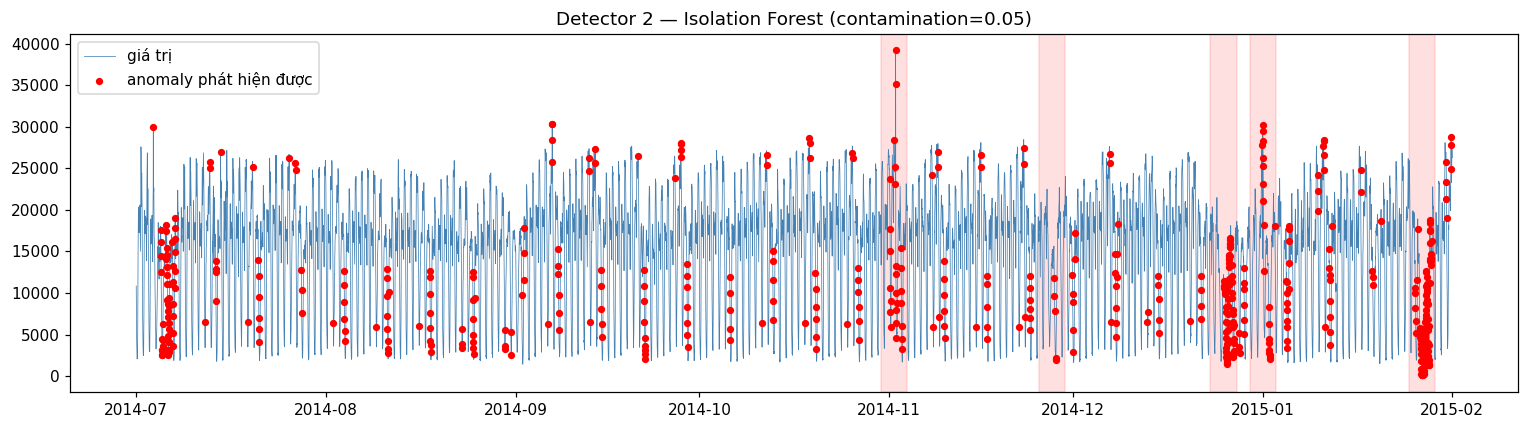

In [14]:
# Chọn contamination tốt nhất theo F1 và chốt Detector 2
best_c = if_sweep_df["f1"].idxmax()
clf_if, pred_if = if_models[best_c]
m_if = evaluate(pred_if.values, gt_X.values)
ec_if = events_caught(pred_if)
print(f"contamination được chọn = {best_c} (F1 tốt nhất)")
print("Detector 2 (IF):", m_if, f"sự kiện={ec_if[0]}/{ec_if[1]}")
plot_detector(pred_if, f"Detector 2 — Isolation Forest (contamination={best_c})",
              "figures/07_detector2_if.png")

## Phase 3 — So sánh, Tuning & Reflection

                        TP     FP     FN  precision  recall     f1  false_alarm_rate events_caught
Detector 1 (STL+3σ)  194.0   61.0  841.0      0.761   0.187  0.301            0.0066           5/5
Detector 2 (IF)      205.0  309.0  830.0      0.399   0.198  0.265            0.0335           5/5


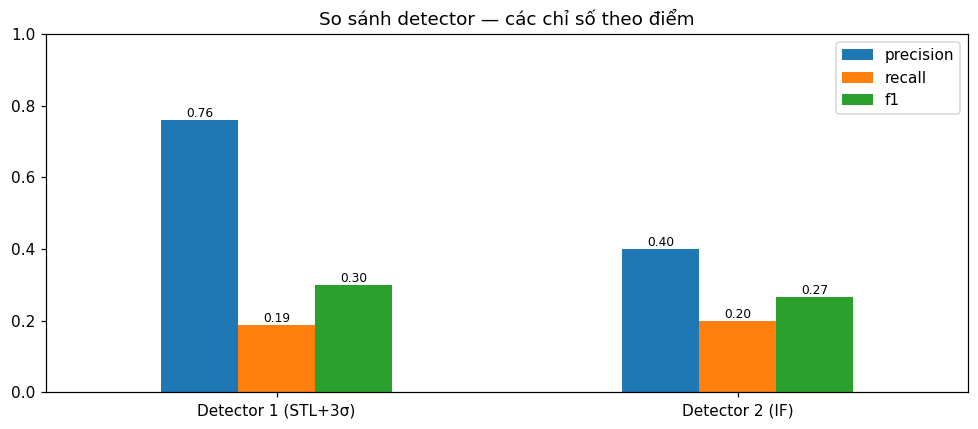

In [15]:
# So sánh song song (theo điểm, đánh giá trên cùng index feature cho công bằng)
gt_common = gt.loc[X.index]
cmp = pd.DataFrame({
    "Detector 1 (STL+3σ)": evaluate(pred_stl.loc[X.index].values, gt_common.values),
    "Detector 2 (IF)":     evaluate(pred_if.values, gt_common.values),
}).T
cmp["events_caught"] = [f"{events_caught(pred_stl)[0]}/5",
                        f"{events_caught(pred_if)[0]}/5"]
print(cmp.to_string())

# Biểu đồ cột so sánh
ax = cmp[["precision", "recall", "f1"]].plot.bar(figsize=(9, 4), rot=0)
ax.set_title("So sánh detector — các chỉ số theo điểm")
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout()
plt.savefig("figures/08_comparison.png", bbox_inches="tight")
plt.show()

In [16]:
# Các thí nghiệm tuning (>=3 lần) — ghi lại kết quả
print("=== Log tuning ===")
tuning = []

# (a) Quét threshold của STL
for thr in (2.5, 3.0, 3.5):
    p = (z_resid.abs() > thr)
    m = evaluate(p.values, gt.values)
    ec = events_caught(p)
    tuning.append(dict(detector="STL", param=f"threshold={thr}",
                       precision=m["precision"], recall=m["recall"],
                       f1=m["f1"], FP=m["FP"], events=f"{ec[0]}/5"))

# (b) Quét contamination của IF (từ phần trước)
for c in (0.01, 0.02, 0.05):
    _, p = if_models[c]
    m = evaluate(p.values, gt_X.values)
    ec = events_caught(p)
    tuning.append(dict(detector="IF", param=f"contamination={c}",
                       precision=m["precision"], recall=m["recall"],
                       f1=m["f1"], FP=m["FP"], events=f"{ec[0]}/5"))

tuning_df = pd.DataFrame(tuning)
print(tuning_df.to_string(index=False))

=== Log tuning ===
detector              param  precision  recall    f1  FP events
     STL      threshold=2.5      0.701   0.224 0.340  99    5/5
     STL      threshold=3.0      0.761   0.187 0.301  61    5/5
     STL      threshold=3.5      0.770   0.156 0.259  48    5/5
      IF contamination=0.01      0.825   0.082 0.149  18    4/5
      IF contamination=0.02      0.602   0.120 0.200  82    4/5
      IF contamination=0.05      0.399   0.198 0.265 309    5/5


In [17]:
# Lưu artifact model Isolation Forest đã train (mục tiêu < 1 MB)
import os
joblib.dump(clf_if, "models/isolation_forest.joblib", compress=3)
size_kb = os.path.getsize("models/isolation_forest.joblib") / 1024
print(f"đã lưu models/isolation_forest.joblib  ({size_kb:.1f} KB)")
assert size_kb < 1024, "artifact vượt quá 1 MB"

đã lưu models/isolation_forest.joblib  (764.4 KB)


### Phase 3 — Reflection

**Data thuộc loại gì?** Seasonal (ngày + tuần), non-stationary, lệch trái nhẹ
(gần Gaussian). Không phải ứng viên cho log-transform.

**Vì sao chọn các phương pháp này?** Seasonality loại bỏ global 3σ đơn lẻ (baseline ở
trên có band rộng hơn cả data và bỏ sót các đợt tụt ngày lễ). **STL+3σ** bỏ cấu trúc
ngày/tuần và chấm điểm trên residual, cho **precision** cao nhất. **Isolation Forest**
trên các feature thời gian đánh đổi precision để có thể nâng recall qua núm
`contamination` và tổng quát hóa sang bối cảnh multivariate.

**Cái nào tốt hơn / đánh đổi?** Theo F1 theo điểm thì **STL thắng** (sạch hơn, ít
false alarm hơn, và giải thích được cho đội ops). IF cần feature engineering và một
`contamination` đã tune, lại khó giải thích hơn — nhưng nó scale được lên *nhiều*
metric cùng lúc, điều STL không làm được. Lưu ý recall theo điểm thấp với *cả hai* vì
nhãn là cửa sổ 4 ngày trong khi sự kiện thì sắc nhọn; ở **mức sự kiện cả hai bắt được
5/5 (hoặc 4–5/5)** sự cố đã biết, đây mới là cái quan trọng cho việc paging.

**Lựa chọn cho production:** STL+3σ (hoặc seasonal-ESD) làm detector first-pass thiên
về recall cho từng metric; Isolation Forest làm bộ lọc multivariate second-pass khi
cần tương quan nhiều metric với nhau. Đặt threshold thiên về **recall** — trong AIOps
bỏ sót một outage tốn kém hơn nhiều so với một lần báo nhầm.

## Bonus

1. Detector drift EWMA (α=0.1) so với STL
2. Thí nghiệm log-transform trên data (lệch trái) này
3. Isolation Forest univariate so với multivariate

EWMA(α=0.1) trên taxi gốc: {'TP': 0, 'FP': 0, 'FN': 1035, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'false_alarm_rate': 0.0} sự kiện=0/5  -> sai công cụ cho spike seasonal

Memory leak giả lập (drift bắt đầu t=300) — trung bình |độ lệch| ở vùng drift ổn định:
  rolling-mean(60): 1.96σ  (dưới 3σ -> BỎ SÓT rò rỉ)
  EWMA(α=0.01):     6.08σ  (trên 3σ -> BẮT ĐƯỢC rò rỉ)


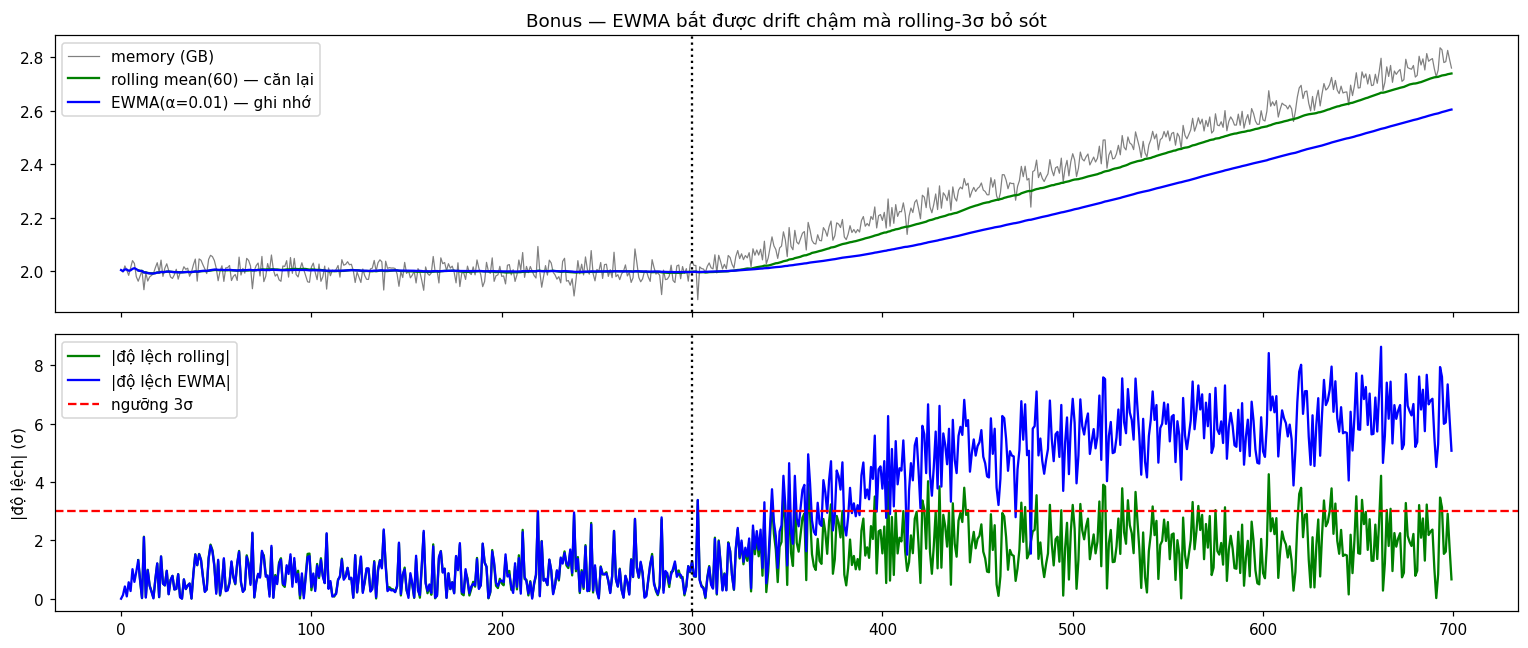

In [18]:
# Bonus 1 — EWMA(α=0.1) là detector DRIFT, không phải detector spike seasonal.
# (a) Trên chuỗi taxi seasonal, std EWMA giãn nở hấp thụ luôn dao động ngày/tuần,
#     nên độ lệch hiếm khi vượt 3σ và EWMA gần như không flag gì.
alpha = 0.1
ewma = s.ewm(alpha=alpha).mean()
ewma_std = s.ewm(alpha=alpha).std().replace(0, 1e-10)
pred_ewma = ((s - ewma).abs() / ewma_std > 3.0)
print(f"EWMA(α={alpha}) trên taxi gốc:", evaluate(pred_ewma.values, gt.values),
      f"sự kiện={events_caught(pred_ewma)[0]}/5  -> sai công cụ cho spike seasonal")

# (b) Nơi EWMA thắng: một drift 'memory-leak' chậm mà rolling window BỎ SÓT.
#     Rolling mean tự căn lại theo data đã trôi (độ lệch sụp về 0), trong khi
#     trí nhớ mũ dài của EWMA cứ tụt lại phía sau -> độ lệch lớn dần.
rng = np.random.default_rng(0)
n = 700
mem = pd.Series(np.concatenate([np.full(300, 2.0), 2.0 + 0.002 * np.arange(400)])
                + rng.normal(0, 0.03, n))     # GB; phẳng, rồi rò rỉ chậm từ t=300
base_std = mem[:300].std()
roll_mean = mem.rolling(60, min_periods=10).mean()
ewma_mem = mem.ewm(alpha=0.01).mean()
roll_dev = (mem - roll_mean) / base_std
ewma_dev = (mem - ewma_mem) / base_std
steady = slice(500, None)
print("\nMemory leak giả lập (drift bắt đầu t=300) — trung bình |độ lệch| ở vùng drift ổn định:")
print(f"  rolling-mean(60): {roll_dev[steady].abs().mean():.2f}σ  (dưới 3σ -> BỎ SÓT rò rỉ)")
print(f"  EWMA(α=0.01):     {ewma_dev[steady].abs().mean():.2f}σ  (trên 3σ -> BẮT ĐƯỢC rò rỉ)")

fig, axx = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axx[0].plot(mem.index, mem, color="gray", lw=0.8, label="memory (GB)")
axx[0].plot(roll_mean.index, roll_mean, color="green", label="rolling mean(60) — căn lại")
axx[0].plot(ewma_mem.index, ewma_mem, color="blue", label="EWMA(α=0.01) — ghi nhớ")
axx[0].axvline(300, color="black", ls=":")
axx[0].legend(); axx[0].set_title("Bonus — EWMA bắt được drift chậm mà rolling-3σ bỏ sót")
axx[1].plot(roll_dev.index, roll_dev.abs(), color="green", label="|độ lệch rolling|")
axx[1].plot(ewma_dev.index, ewma_dev.abs(), color="blue", label="|độ lệch EWMA|")
axx[1].axhline(3, color="red", ls="--", label="ngưỡng 3σ")
axx[1].axvline(300, color="black", ls=":")
axx[1].legend(); axx[1].set_ylabel("|độ lệch| (σ)")
plt.tight_layout()
plt.savefig("figures/09_ewma.png", bbox_inches="tight")
plt.show()

In [19]:
# Bonus 2 — log-transform: KHI NÀO nó giúp ích? Tùy vào DẤU của skew.
# (a) Chuỗi taxi thật bị lệch TRÁI, nên log không phù hợp và làm xấu hơn.
print(f"skew taxi gốc = {stats.skew(s):.3f}  ->  log1p = {stats.skew(np.log1p(s)):.3f}"
      "  (|skew| tăng -> log KHÔNG phù hợp với metric lệch trái này)")

# (b) Một chuỗi latency lệch PHẢI (đúng nơi quy tắc của bài học áp dụng): log chuẩn hóa
#     đuôi phải nặng, sửa cận dưới âm vô nghĩa và cắt bớt false alarm mà đuôi dài gây ra
#     dưới 3σ thô.
rng = np.random.default_rng(1)
m = 2000
latency = rng.lognormal(mean=4.0, sigma=0.5, size=m)      # latency lệch phải (ms)
spike_idx = rng.choice(m, 15, replace=False)
latency[spike_idx] *= 5                                   # spike chèn vào = anomaly
lat_label = np.zeros(m, dtype=bool); lat_label[spike_idx] = True
latency = pd.Series(latency)


def global_3sigma(x):
    up, lo = x.mean() + 3 * x.std(), x.mean() - 3 * x.std()
    return ((x > up) | (x < lo)), lo, up


p_raw, lo_raw, up_raw = global_3sigma(latency)
p_log, _, _ = global_3sigma(np.log1p(latency))
print(f"\nskew latency gốc = {stats.skew(latency):.2f}  ->  log1p = {stats.skew(np.log1p(latency)):.2f}")
print(f"band 3σ thô = [{lo_raw:.0f}, {up_raw:.0f}]  (cận dưới < 0 -> ngưỡng latency vô nghĩa)")
print("3σ thô :", evaluate(p_raw.values, lat_label))
print("3σ log :", evaluate(p_log.values, lat_label))
print("-> log-transform cắt mạnh false alarm (precision tăng, FP giảm) và bỏ cận dưới "
      "vô nghĩa; đổi lại mất một chút recall do nén spike. Bài học: chỉ transform data "
      "lệch PHẢI, và luôn kiểm tra DẤU của skew trước.")

skew taxi gốc = -0.452  ->  log1p = -1.927  (|skew| tăng -> log KHÔNG phù hợp với metric lệch trái này)

skew latency gốc = 3.07  ->  log1p = 0.21
band 3σ thô = [-52, 179]  (cận dưới < 0 -> ngưỡng latency vô nghĩa)
3σ thô : {'TP': 12, 'FP': 20, 'FN': 3, 'precision': 0.375, 'recall': 0.8, 'f1': 0.511, 'false_alarm_rate': 0.0101}
3σ log : {'TP': 6, 'FP': 4, 'FN': 9, 'precision': 0.6, 'recall': 0.4, 'f1': 0.48, 'false_alarm_rate': 0.002}
-> log-transform cắt mạnh false alarm (precision tăng, FP giảm) và bỏ cận dưới vô nghĩa; đổi lại mất một chút recall do nén spike. Bài học: chỉ transform data lệch PHẢI, và luôn kiểm tra DẤU của skew trước.


In [20]:
# Bonus 3 — Isolation Forest univariate so với multivariate
# Univariate = chỉ cột 'value'; Multivariate = toàn bộ ma trận feature đã engineer.
clf_uni = IsolationForest(n_estimators=200, contamination=best_c,
                          random_state=42).fit(X[["value"]])
pred_uni = pd.Series(clf_uni.predict(X[["value"]]) == -1, index=X.index)
m_uni = evaluate(pred_uni.values, gt_X.values)
m_multi = evaluate(pred_if.values, gt_X.values)   # IF đầy đủ feature từ Phase 2
print("IF univariate (chỉ value):", m_uni, f"sự kiện={events_caught(pred_uni)[0]}/5")
print("IF multivariate (11 feat) :", m_multi, f"sự kiện={events_caught(pred_if)[0]}/5")
print("Thêm các feature thời gian/ngữ cảnh giúp IF dùng được ngữ cảnh seasonal "
      "(giờ, thứ trong tuần, độ lệch so với trend) thay vì chỉ độ lớn thô.")

IF univariate (chỉ value): {'TP': 80, 'FP': 431, 'FN': 955, 'precision': 0.157, 'recall': 0.077, 'f1': 0.103, 'false_alarm_rate': 0.0467} sự kiện=5/5
IF multivariate (11 feat) : {'TP': 205, 'FP': 309, 'FN': 830, 'precision': 0.399, 'recall': 0.198, 'f1': 0.265, 'false_alarm_rate': 0.0335} sự kiện=5/5
Thêm các feature thời gian/ngữ cảnh giúp IF dùng được ngữ cảnh seasonal (giờ, thứ trong tuần, độ lệch so với trend) thay vì chỉ độ lớn thô.


### Bonus — điểm rút ra

- **EWMA(α=0.1)** là detector drift: trên chuỗi taxi seasonal nó gần như không flag gì
  (std giãn nở hấp thụ dao động), nhưng trên một rò rỉ chậm giả lập nó bắt được drift
  (trung bình ≈6σ) mà rolling window bỏ sót (trung bình ≈2σ).
- **Log-transform** chỉ sửa lệch *phải*; trên chuỗi taxi lệch trái nó làm xấu hơn, còn
  trên chuỗi latency lệch phải nó cắt false alarm và bỏ cận dưới âm vô nghĩa — hãy kiểm
  tra **dấu** của skew trước khi transform.
- **IF multivariate** (các feature đã engineer) thắng IF univariate vì ở đây anomaly
  được nhìn rõ nhất dưới dạng *độ lệch so với ngữ cảnh seasonal*, không phải độ lớn thô.

### Tổng kết
Data seasonal, non-stationary, gần Gaussian → **STL+3σ** là detector đơn-metric tốt
nhất (precision cao, giải thích được); **Isolation Forest** là phần bổ trợ multivariate.
Cả hai đều bắt được sự cố thật; tune thiên về recall cho việc paging trong production.